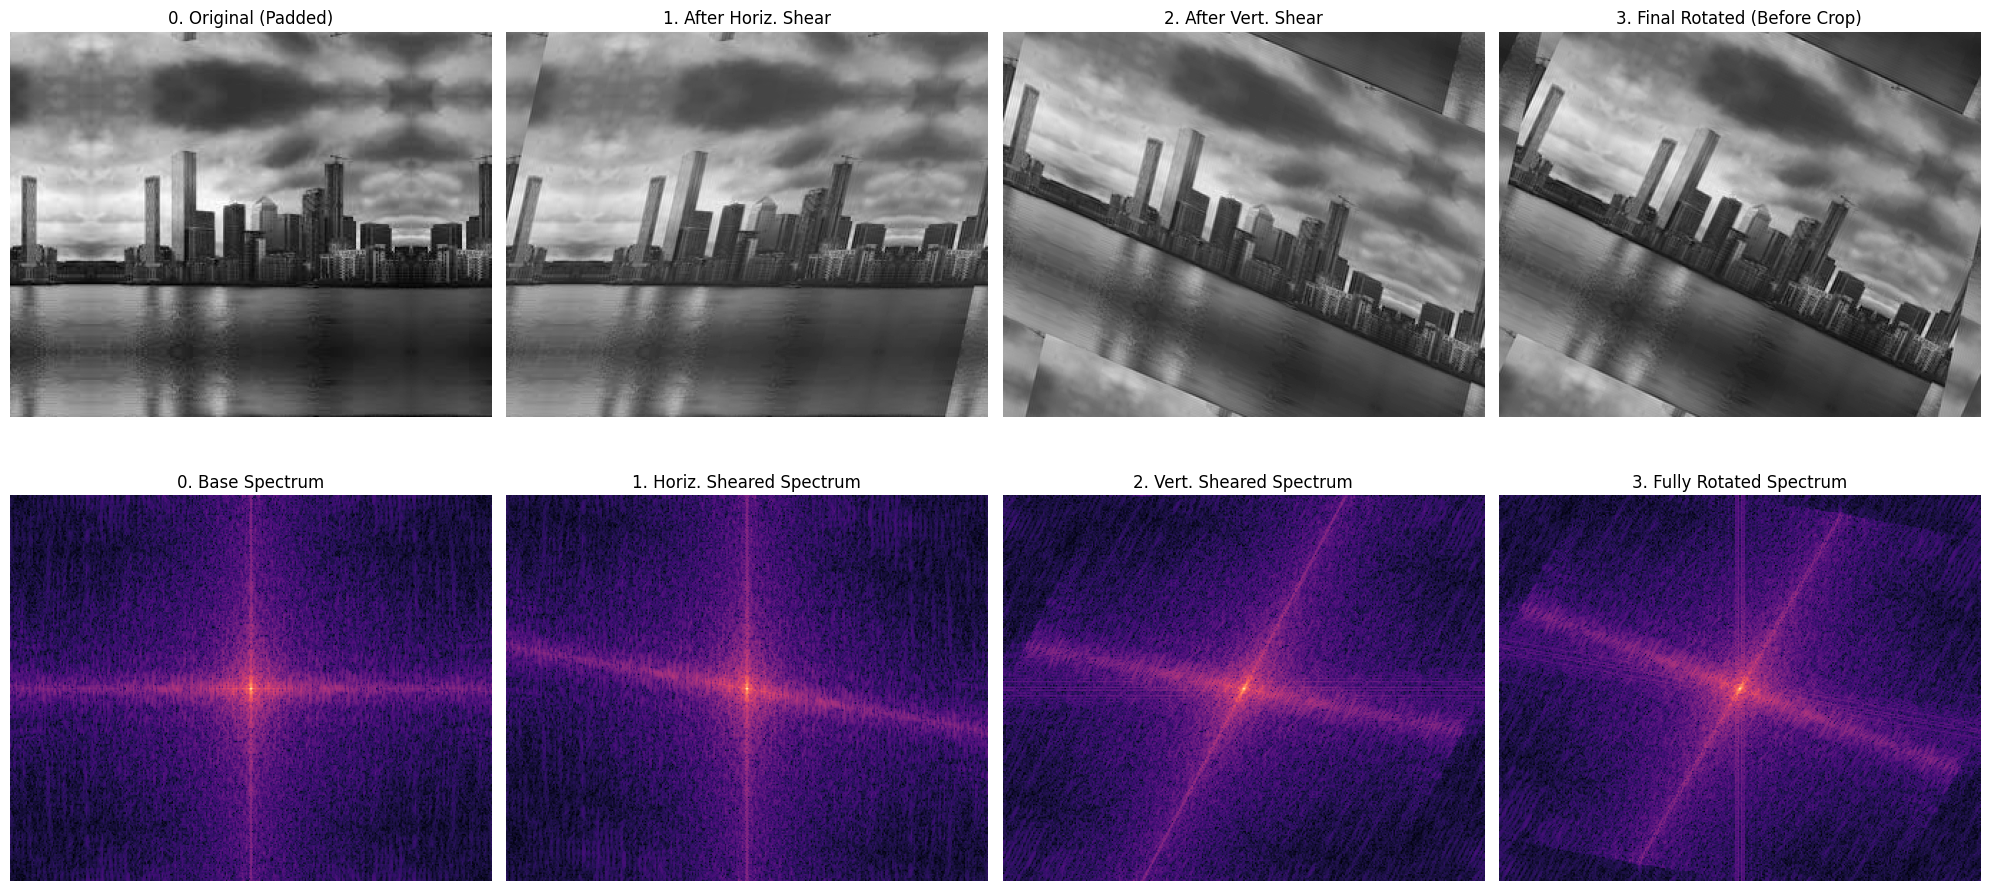

In [8]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import cv2

def shift_rows(image: torch.Tensor, shifts: torch.Tensor) -> torch.Tensor:
    H, W = image.shape
    F_freq = torch.fft.fft(image, dim=1)
    u = torch.fft.fftfreq(W, device=image.device)
    phase = -2j * torch.pi * shifts.unsqueeze(1) * u.unsqueeze(0)
    return torch.real(torch.fft.ifft(F_freq * torch.exp(phase), dim=1))

def get_magnitude_spectrum(image: torch.Tensor) -> torch.Tensor:
    """Helper to compute the centered log magnitude spectrum of a spatial image."""
    F_2d = torch.fft.fft2(image)
    F_shifted = torch.fft.fftshift(F_2d)
    return torch.log(1 + torch.abs(F_shifted))

def rotate_and_capture_intermediates(image: torch.Tensor, angle_deg: float) -> dict:
    """
    Rotates an image using the 3-shear method and captures both the spatial 
    and frequency domain representations at every intermediate step.
    """
    H, W = image.shape
    angle_rad = angle_deg * (torch.pi / 180.0)
    
    alpha = -torch.tan(torch.tensor(angle_rad / 2.0))
    beta = torch.sin(torch.tensor(angle_rad))
    
    y_coords = torch.arange(H, device=image.device, dtype=torch.float32) - (H - 1) / 2.0
    x_coords = torch.arange(W, device=image.device, dtype=torch.float32) - (W - 1) / 2.0
    
    # Capture initial state
    intermediates = {
        'step0_spatial': image.clone(),
        'step0_freq': get_magnitude_spectrum(image)
    }
    
    # 1. First Horizontal Shear
    shifts_x1 = alpha * y_coords
    out_step1 = shift_rows(image, shifts_x1)
    intermediates['step1_spatial'] = out_step1.clone()
    intermediates['step1_freq'] = get_magnitude_spectrum(out_step1)
    
    # 2. Vertical Shear
    shifts_y = beta * x_coords
    out_step2 = shift_rows(out_step1.t(), shifts_y).t()
    intermediates['step2_spatial'] = out_step2.clone()
    intermediates['step2_freq'] = get_magnitude_spectrum(out_step2)
    
    # 3. Second Horizontal Shear
    out_step3 = shift_rows(out_step2, shifts_x1)
    intermediates['step3_spatial'] = out_step3.clone()
    intermediates['step3_freq'] = get_magnitude_spectrum(out_step3)
    
    return intermediates

# --- 1. Load your uploaded skyline image ---
img_np = cv2.imread('my_photo.jpeg', cv2.IMREAD_GRAYSCALE)
img = torch.tensor(img_np, dtype=torch.float32) / 255.0

# --- 2. Apply reflection padding ---
img_4d = img.unsqueeze(0).unsqueeze(0)
orig_H, orig_W = img.shape
pad_h, pad_w = orig_H // 4, orig_W // 4
padded_img = F.pad(img_4d, (pad_w, pad_w, pad_h, pad_h), mode='reflect').squeeze(0).squeeze(0)

# --- 3. Execute and capture all stages ---
rotation_angle = 25.0
data = rotate_and_capture_intermediates(padded_img, rotation_angle)

# --- 4. Plot the Step-by-Step Evolution ---
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

titles_spatial = [
    "0. Original (Padded)", 
    "1. After Horiz. Shear", 
    "2. After Vert. Shear", 
    "3. Final Rotated (Before Crop)"
]
titles_freq = [
    "0. Base Spectrum", 
    "1. Horiz. Sheared Spectrum", 
    "2. Vert. Sheared Spectrum", 
    "3. Fully Rotated Spectrum"
]

keys_spatial = ['step0_spatial', 'step1_spatial', 'step2_spatial', 'step3_spatial']
keys_freq = ['step0_freq', 'step1_freq', 'step2_freq', 'step3_freq']

for i in range(4):
    # Top Row: Spatial Domain
    spatial_img = data[keys_spatial[i]].numpy()
    axes[0, i].imshow(spatial_img, cmap='gray')
    axes[0, i].set_title(titles_spatial[i], fontsize=12)
    axes[0, i].axis('off')
    
    # Bottom Row: 2D Frequency Domain Magnitude
    freq_img = data[keys_freq[i]].numpy()
    axes[1, i].imshow(freq_img, cmap='magma')
    axes[1, i].set_title(titles_freq[i], fontsize=12)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
IMG_PATH = '/home/xz127/earth_project/Reconstruction/test3_1600_1200.jpg'
# --- 1. Load your uploaded skyline image ---
img_np = cv2.imread(IMG_PATH, cv2.IMREAD_COLOR)
img_np = cv2.cvtColor(img_np, cv2.COLOR_BGR2RGB)
img = torch.tensor(img_np, dtype=torch.float32) / 255.0

# --- 2. Apply reflection padding ---
img_4d = img.permute(2, 0, 1).unsqueeze(0)
orig_H, orig_W = img.shape[:2]
pad_h, pad_w = orig_H // 4, orig_W // 4
padded_img = F.pad(img_4d, (pad_w, pad_w, pad_h, pad_h), mode='reflect').squeeze(0).permute(1, 2, 0)

# --- 3. Execute and capture all stages ---
rotation_angle = 90.0
data = rotate_and_capture_intermediates(padded_img, rotation_angle)

# --- 4. Plot the Step-by-Step Evolution ---
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

titles_spatial = [
    "0. Original (Padded)", 
    "1. After Horiz. Shear", 
    "2. After Vert. Shear", 
    "3. Final Rotated (Before Crop)"
]
titles_freq = [
    "0. Base Spectrum", 
    "1. Horiz. Sheared Spectrum", 
    "2. Vert. Sheared Spectrum", 
    "3. Fully Rotated Spectrum"
]

keys_spatial = ['step0_spatial', 'step1_spatial', 'step2_spatial', 'step3_spatial']
keys_freq = ['step0_freq', 'step1_freq', 'step2_freq', 'step3_freq']

for i in range(4):
    # Top Row: Spatial Domain
    spatial_img = data[keys_spatial[i]].numpy()
    axes[0, i].imshow(spatial_img.clip(0, 1))
    axes[0, i].set_title(titles_spatial[i], fontsize=12)
    axes[0, i].axis('off')
    
    # Bottom Row: 2D Frequency Domain Magnitude (averaged across channels for display)
    freq_img = data[keys_freq[i]].mean(dim=2).numpy()
    axes[1, i].imshow(freq_img, cmap='magma')
    axes[1, i].set_title(titles_freq[i], fontsize=12)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()